# Masterclass 1b: Comparing the speeches

The corpus one speech at a time. Which words mark a speech out, and which speeches resemble each other.

## Today's goal

1. Find each speech's most distinctive words, rather than its commonest ones.
2. Draw hierarchical-clustering dendrograms, varying the metric and the time slice.
3. Compare word clouds across presidential eras.

Everything below needs the matrices we built in 1a. This cell rebuilds them in one go, so nothing here is new: it is the same pipeline, written out slowly there and collected here.

Read it as a summary of 1a rather than as new material. If a line looks unfamiliar, it is worth going back to where 1a introduced it.

In [1]:
import re
import sotu
import pandas
import matplotlib.pyplot as plt
import sklearn.feature_extraction.text
import scipy.spatial.distance
import scipy.cluster.hierarchy
import nltk.stem
from corpus_tools import comparison_cloud

df = sotu.load()
labels = (df['year'].astype(str) + ' ' + df['president']).tolist()

# The raw count matrix, as in 1a.
vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    lowercase=True,
    stop_words='english',
)
dfm = vectorizer.fit_transform(df['text'])
features = vectorizer.get_feature_names_out()
dfm_df = pandas.DataFrame(dfm.toarray(), index=labels, columns=features)
corpus_totals = dfm_df.sum(axis=0).sort_values(ascending=False)

# The stemmed, trimmed matrix, as in 1a.
stemmer = nltk.stem.SnowballStemmer('english')
stemmed_docs = []
for text in df['text']:
    roots = []
    for word in text.lower().split():
        roots.append(stemmer.stem(word))
    stemmed_docs.append(' '.join(roots))

stem_vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    stop_words='english',
    min_df=3,
)
stem_counts = stem_vectorizer.fit_transform(stemmed_docs).toarray()
stem_features = stem_vectorizer.get_feature_names_out()
keep = stem_counts.sum(axis=0) >= 5
stem_counts = stem_counts[:, keep]
stem_features = stem_features[keep]

print(f'{len(df)} speeches, {dfm.shape[1]:,} features, {stem_counts.shape[1]:,} stemmed.')

237 speeches, 26,013 features, 10,173 stemmed.


In [2]:
# Top 10 words for each of the first three individual speeches.
for row_index in range(3):
    top = dfm_df.iloc[row_index].sort_values(ascending=False).head(10)
    print(f'\n{labels[row_index]}:')
    for word, count in top.items():
        print(f'    {word}: {int(count)}')


1790 Washington:
    public: 5
    measures: 4
    states: 4
    end: 4
    great: 4
    united: 4
    country: 4
    government: 4
    regard: 4
    citizens: 3

1790 Washington:
    citizens: 5
    public: 5
    means: 4
    national: 4
    great: 4
    present: 4
    country: 4
    commerce: 4
    certain: 3
    house: 3

1791 Washington:
    united: 16
    states: 16
    public: 10
    proper: 7
    important: 7
    government: 7
    law: 6
    provision: 6
    measures: 6
    objects: 6


Six of Washington's ten also sit in the corpus top twenty. These are the words the whole corpus uses most, which is not the same as the words that make one speech unlike the others.

Distinctive means a word this speech leans on more than the corpus does overall. Work out how often this speech uses it, how often the whole corpus uses it, and divide. A word used at the ordinary rate scores about one.

`speech_counts >= 3` drops words used once or twice, which would otherwise head the list on a single mention. Dividing one set of counts by the other matches them up word by word, so every ratio compares a word with itself.

In [3]:
corpus_grand_total = corpus_totals.sum()

for row_index in range(3):
    speech_counts = dfm_df.iloc[row_index]
    speech_total = speech_counts.sum()
    frequent = speech_counts[speech_counts >= 3]
    speech_rates = frequent / speech_total
    corpus_rates = corpus_totals[frequent.index] / corpus_grand_total
    ratios = (speech_rates / corpus_rates).sort_values(ascending=False)

    print(f'\n{labels[row_index]}:')
    for word, ratio in ratios.head(10).items():
        print(f'    {word}: {ratio:.0f} times its corpus rate')


1790 Washington:
    render: 29 times its corpus rate
    object: 14 times its corpus rate
    regard: 13 times its corpus rate
    information: 12 times its corpus rate
    ought: 11 times its corpus rate
    end: 10 times its corpus rate
    affairs: 10 times its corpus rate
    representatives: 10 times its corpus rate
    house: 9 times its corpus rate
    measures: 9 times its corpus rate

1790 Washington:
    requisite: 49 times its corpus rate
    militia: 29 times its corpus rate
    valuable: 23 times its corpus rate
    particularly: 17 times its corpus rate
    objects: 15 times its corpus rate
    fellow: 12 times its corpus rate
    representatives: 8 times its corpus rate
    house: 8 times its corpus rate
    established: 7 times its corpus rate
    certain: 6 times its corpus rate

1791 Washington:
    subscriptions: 273 times its corpus rate
    situations: 104 times its corpus rate
    pleasing: 97 times its corpus rate
    naturally: 40 times its corpus rate
    gen

Not one of these is a corpus top-twenty word. Washington's first address is about render, object, regard and information, and his second about requisite, militia and valuable.

The same words, counted the same way. All that changed is what they are compared against, and that is the difference between frequent and distinctive.

Row-normalise the stemmed, trimmed matrix: divide each row by its total, so long speeches do not dominate the pairwise distances. After this every row sums to 1.

In [4]:
dfm_dense = stem_counts.astype(float)
row_totals = dfm_dense.sum(axis=1, keepdims=True)
row_totals[row_totals == 0] = 1.0
normalised = dfm_dense / row_totals
print(f'Row-sum range: {normalised.sum(axis=1).min():.3f} to {normalised.sum(axis=1).max():.3f}')

Row-sum range: 1.000 to 1.000


A helper, because five cells below draw the same kind of picture. Given a matrix, its labels, a distance metric and a title, it draws the hierarchical-clustering dendrogram.

Three of its inputs are written as `name=value`. That makes them optional, so a caller who says nothing about `figsize` gets the value written here, and one who needs a wider figure passes its own.

In [5]:
def render_dendrogram(matrix, leaf_labels, metric, title, figsize=(14, 6),
                      leaf_font_size=7, save_path=None):
    distances = scipy.spatial.distance.pdist(matrix, metric=metric)
    linkage = scipy.cluster.hierarchy.linkage(distances, method='complete')
    plt.figure(figsize=figsize)
    scipy.cluster.hierarchy.dendrogram(
        linkage,
        labels=leaf_labels,
        leaf_rotation=90,
        leaf_font_size=leaf_font_size,
    )
    plt.title(title)
    if save_path is not None:
        # Save before show. Showing the figure clears it, so a savefig after
        # plt.show() writes a blank page.
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print('Wrote', save_path)
    plt.show()

Those labels are 4 point. They are unreadable at this width and always will be, because 237 speeches do not fit across a screen. `plt.savefig` writes the same figure to a file, which your PDF reader will happily zoom to 800%.

A PDF stores lines and text rather than pixels, so zooming never blurs and you can search the file for a president. It is also smaller on disk than a PNG of the same figure.

Wrote sotu-dendrogram.pdf


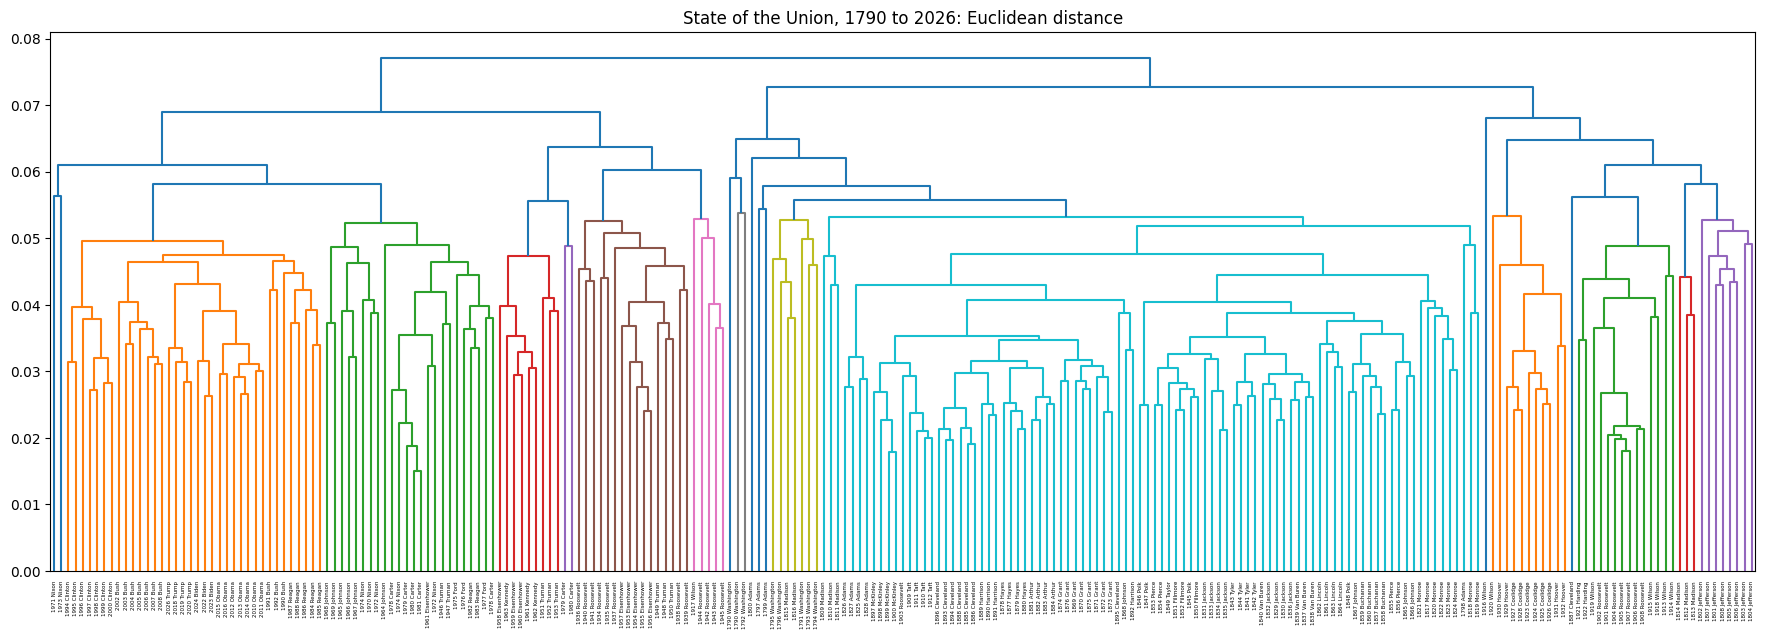

In [6]:
render_dendrogram(
    normalised,
    labels,
    metric='euclidean',
    title='State of the Union, 1790 to 2026: Euclidean distance',
    figsize=(22, 7),
    leaf_font_size=4,
    save_path='sotu-dendrogram.pdf',
)

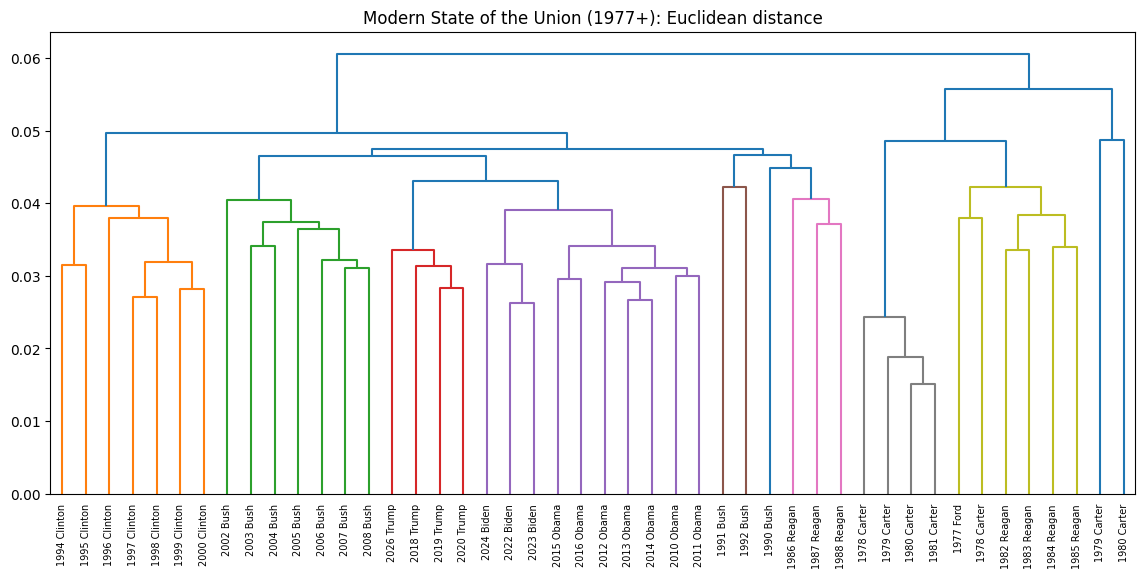

In [7]:
# Modern subset, Euclidean distance.
modern_mask = (df['year'] >= 1977).to_numpy()
modern_matrix = normalised[modern_mask]
modern_labels = []
for position in range(len(labels)):
    if modern_mask[position]:
        modern_labels.append(labels[position])

render_dendrogram(
    modern_matrix,
    modern_labels,
    metric='euclidean',
    title='Modern State of the Union (1977+): Euclidean distance',
)

The same modern subset, now under cosine distance. Cosine measures the angle between two count vectors and ignores their magnitude.

scipy's `cosine` is one minus the cosine similarity, so the most similar speeches sit closest together. It is a dissimilarity rather than a true distance, because it can rate a pair as further apart than the route through a third speech.

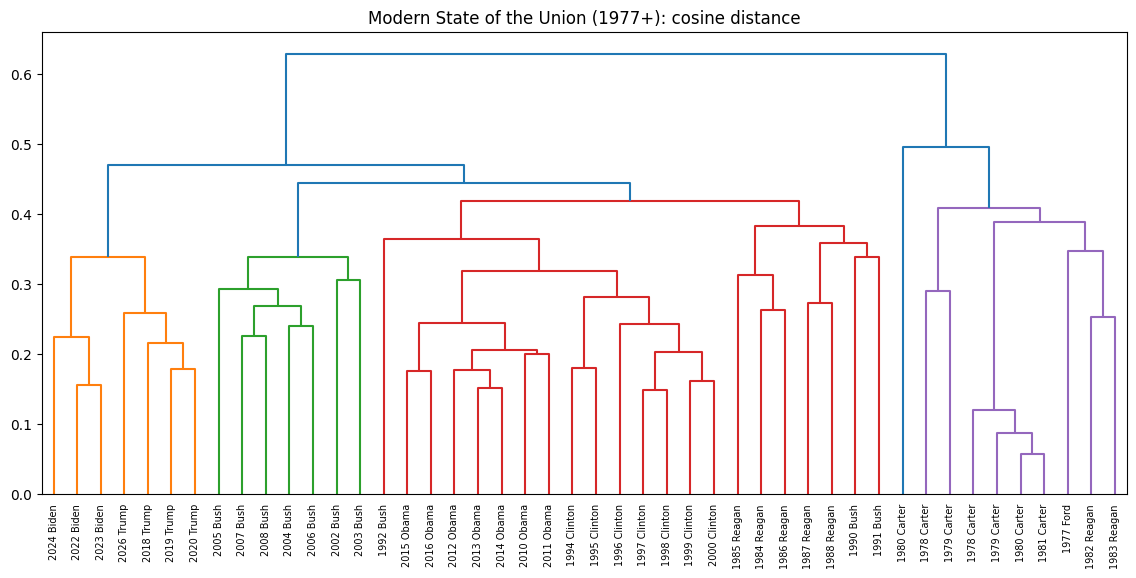

In [8]:
render_dendrogram(
    modern_matrix,
    modern_labels,
    metric='cosine',
    title='Modern State of the Union (1977+): cosine distance',
)

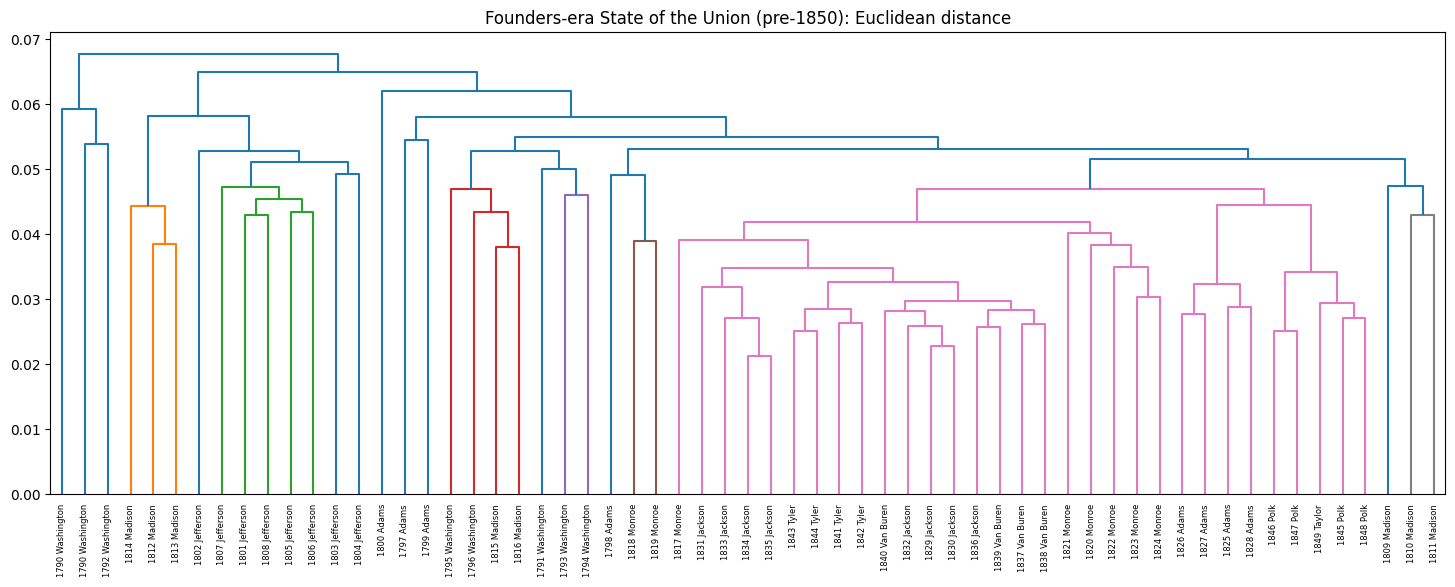

In [9]:
# Founders era, Euclidean distance.
founders_mask = (df['year'] < 1850).to_numpy()
founders_matrix = normalised[founders_mask]
founders_labels = []
for position in range(len(labels)):
    if founders_mask[position]:
        founders_labels.append(labels[position])

render_dendrogram(
    founders_matrix,
    founders_labels,
    metric='euclidean',
    title='Founders-era State of the Union (pre-1850): Euclidean distance',
    figsize=(18, 6),
    leaf_font_size=6,
)

The founders era under cosine distance. Compare the four dendrograms above and ask which pairs of speeches cluster together whichever metric and time slice you use.

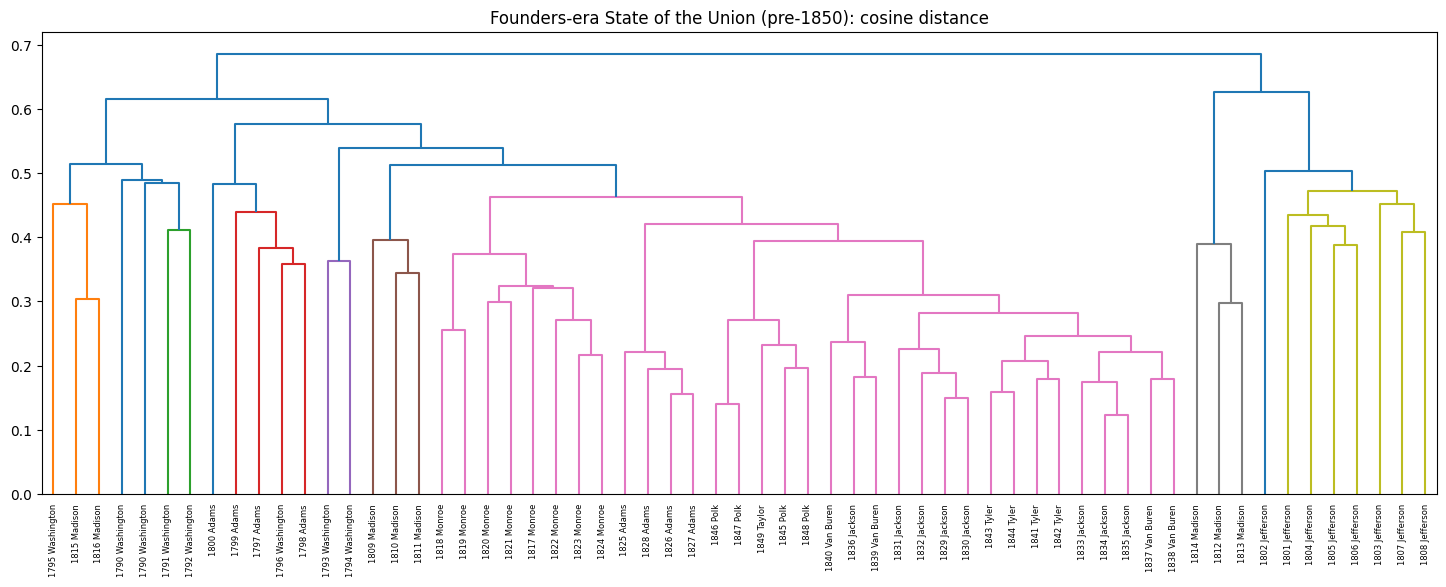

In [10]:
render_dendrogram(
    founders_matrix,
    founders_labels,
    metric='cosine',
    title='Founders-era State of the Union (pre-1850): cosine distance',
    figsize=(18, 6),
    leaf_font_size=6,
)

The corpus records presidents by surname, and a surname is not always one person. Adams, Bush, Johnson and Roosevelt each cover two different presidents.

Cleveland and Trump each show two blocks of years with a gap between them, which in their case is one person returning after a break.

These five columns cannot tell that apart from two people sharing a surname. `sotu.load(full=True)` can, because it adds `president_full`, which names the person, and `president_id`, which names the presidency.

We write the names out by hand below anyway, because the reasoning is the lesson rather than the lookup. Checking what your source already knows is the step before deciding to supply it yourself.

In [11]:
full_names = []
for position in range(len(df)):
    surname = df.iloc[position]['president']
    year = df.iloc[position]['year']
    if surname == 'Adams' and year < 1820:
        full_name = 'John Adams'
    elif surname == 'Adams':
        full_name = 'John Quincy Adams'
    elif surname == 'Bush' and year < 1995:
        full_name = 'George H. W. Bush'
    elif surname == 'Bush':
        full_name = 'George W. Bush'
    elif surname == 'Johnson' and year < 1900:
        full_name = 'Andrew Johnson'
    elif surname == 'Johnson':
        full_name = 'Lyndon B. Johnson'
    elif surname == 'Roosevelt' and year < 1920:
        full_name = 'Theodore Roosevelt'
    elif surname == 'Roosevelt':
        full_name = 'Franklin D. Roosevelt'
    else:
        full_name = surname
    full_names.append(full_name)

df['full_name'] = full_names

# Check the four splits landed where they should.
split_names = [
    'John Adams', 'John Quincy Adams',
    'George H. W. Bush', 'George W. Bush',
    'Andrew Johnson', 'Lyndon B. Johnson',
    'Theodore Roosevelt', 'Franklin D. Roosevelt',
]
for name in split_names:
    years = []
    for position in range(len(df)):
        if df.iloc[position]['full_name'] == name:
            years.append(df.iloc[position]['year'])
    print(f'{name:24s} {len(years):2d} speeches, {min(years)} to {max(years)}')

John Adams                4 speeches, 1797 to 1800
John Quincy Adams         4 speeches, 1825 to 1828
George H. W. Bush         3 speeches, 1990 to 1992
George W. Bush            7 speeches, 2002 to 2008
Andrew Johnson            4 speeches, 1865 to 1868
Lyndon B. Johnson         6 speeches, 1964 to 1969
Theodore Roosevelt        8 speeches, 1901 to 1908
Franklin D. Roosevelt    12 speeches, 1934 to 1945


`comparison_for` picks each speaker's first few speeches and hands their rows to `comparison_cloud`, the helper in `corpus_tools` that draws the wedge cloud.

It matches on the cleaned `full_name` column, so asking for Adams can no longer gather two different presidents under one heading.

In [12]:
def comparison_for(speakers, per_speaker):
    chosen = []
    for name in speakers:
        taken = 0
        for position in range(len(df)):
            if df.iloc[position]['full_name'] == name:
                chosen.append(position)
                taken = taken + 1
                if taken >= per_speaker:
                    break
    labels = []
    for position in chosen:
        labels.append(f"{df.iloc[position]['full_name']}-{df.iloc[position]['year']}")
    comparison_cloud(dfm[chosen].toarray(), features, labels)

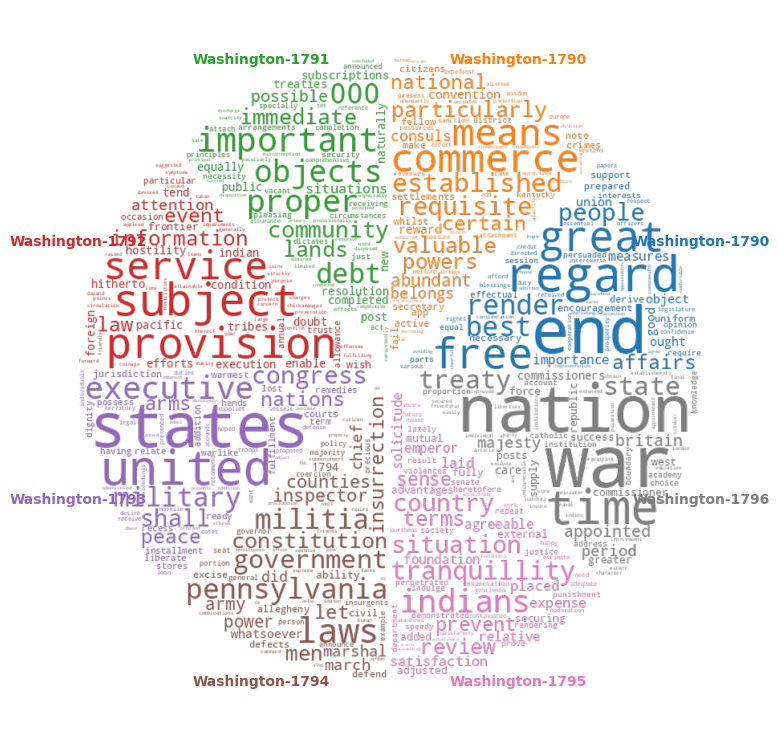

In [13]:
# Washington's eight messages: which words distinguish each from the others.
comparison_for(['Washington'], 8)

John Adams and Jefferson, four speeches each. The cleaned names make the choice unambiguous, because John Quincy Adams would now have to be asked for by his own name.

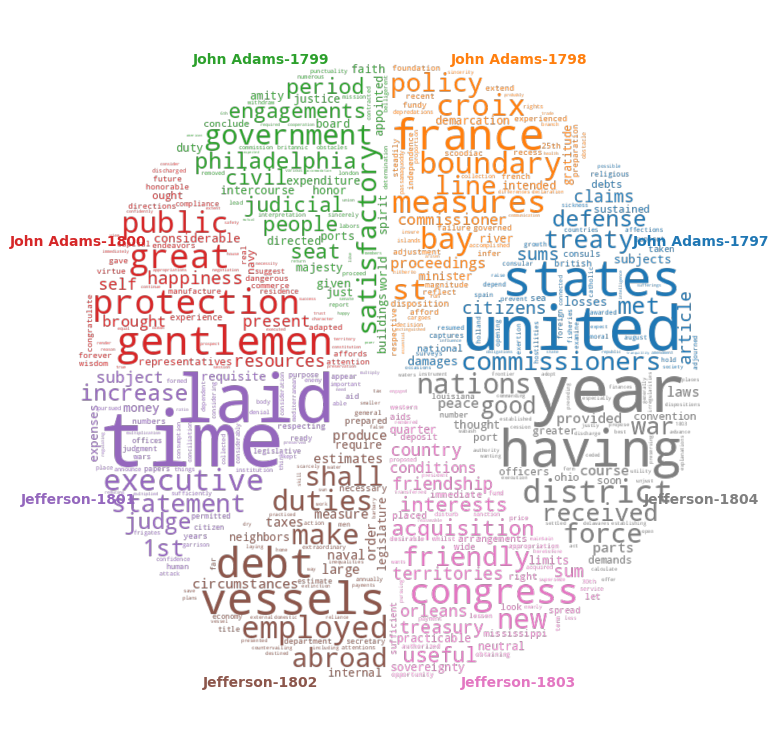

In [14]:
comparison_for(['John Adams', 'Jefferson'], 4)

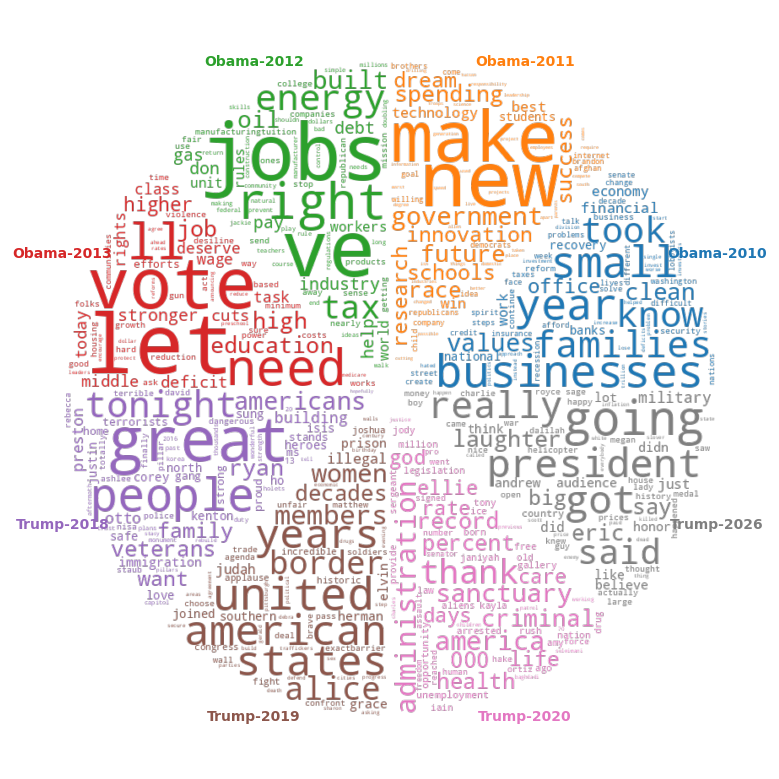

In [15]:
# Obama and Trump, four speeches each.
comparison_for(['Obama', 'Trump'], 4)

## Read more

- **NLTK Book**, Chapter 1: [https://www.nltk.org/book/ch01.html](https://www.nltk.org/book/ch01.html).
- **scikit-learn user guide on text feature extraction**: [https://scikit-learn.org/stable/modules/feature_extraction.html](https://scikit-learn.org/stable/modules/feature_extraction.html).
- **scikit-learn user guide on Latent Dirichlet Allocation**: [https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda](https://scikit-learn.org/stable/modules/decomposition.html#latent-dirichlet-allocation-lda).
- **scipy hierarchical clustering**: [https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html).
- **matplotlib pyplot tutorial**: [https://matplotlib.org/stable/tutorials/pyplot.html](https://matplotlib.org/stable/tutorials/pyplot.html).
- **wordcloud README**: [https://github.com/amueller/word_cloud](https://github.com/amueller/word_cloud).
- **matplotlib named colormaps**: [https://matplotlib.org/stable/tutorials/colors/colormaps.html](https://matplotlib.org/stable/tutorials/colors/colormaps.html).

## What we've covered

**Python**

- functions with default arguments
- building a list of row positions and indexing a matrix with it

**Corpus linguistics**

- per-document top features, and why raw counts return the corpus's commonest words
- distinctive words: ranking a speech by its rate against the corpus rate
- row-normalising a matrix so long speeches do not dominate
- hierarchical clustering with Euclidean and cosine distance
- dendrograms, and reading them at different time slices
- comparison word clouds across presidential eras